In [1]:
import math

def euclidean_distance(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

def get_neighbors(data, point_idx, eps):
    neighbors = []
    for i, point in enumerate(data):
        if euclidean_distance(data[point_idx], point) < eps:
            neighbors.append(i)
    return neighbors

def expand_cluster(data, labels, point_idx, neighbors, cluster_id, eps, min_points):
    labels[point_idx] = cluster_id
    
    # Process all neighbors (using a while loop to allow the list to grow)
    i = 0
    while i < len(neighbors):
        neighbor_idx = neighbors[i]
        
        # If this point was previously marked as Noise, change it to Border point (part of this cluster)
        if labels[neighbor_idx] == -1:
            labels[neighbor_idx] = cluster_id
        
        # If this point has not been visited yet
        elif labels[neighbor_idx] == 0:
            labels[neighbor_idx] = cluster_id
            
            # Find neighbors of this neighbor
            new_neighbors = get_neighbors(data, neighbor_idx, eps)
            
            # If this neighbor is ALSO a core point, add its neighbors to the queue
            if len(new_neighbors) >= min_points:
                neighbors = neighbors + new_neighbors
        
        i += 1

def dbscan(data, eps, min_points):
    # Initialize labels: 0 means unvisited
    labels = [0] * len(data)
    cluster_id = 0
    
    for i in range(len(data)):
        # If point is already visited (has a label other than 0), skip
        if labels[i] != 0:
            continue
        
        neighbors = get_neighbors(data, i, eps)
        
        if len(neighbors) < min_points:
            # Mark as Noise (-1)
            labels[i] = -1
        else:
            # Found a core point, start a new cluster
            cluster_id += 1
            expand_cluster(data, labels, i, neighbors, cluster_id, eps, min_points)
            
    return labels

In [2]:
# Sample 2D data
dataset = [
    [1, 2], [2, 2], [2, 3],    
    [8, 7], [8, 8], [25, 80], 
    [1, 3]                       
]



Data Points: [[1, 2], [2, 2], [2, 3], [8, 7], [8, 8], [25, 80], [1, 3]]
Cluster Labels: [1, 1, 1, 2, 2, -1, 1]
Point [1, 2] -> Cluster 1
Point [2, 2] -> Cluster 1
Point [2, 3] -> Cluster 1
Point [8, 7] -> Cluster 2
Point [8, 8] -> Cluster 2
Point [25, 80] -> Noise
Point [1, 3] -> Cluster 1


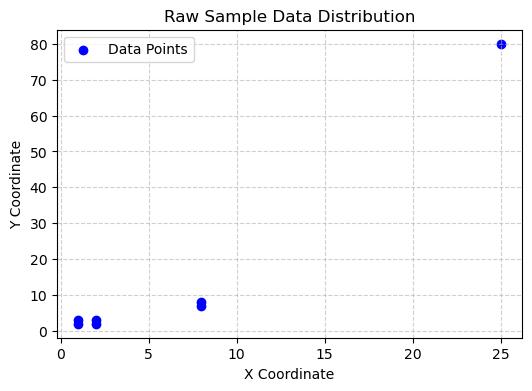

In [7]:
x_coords, y_coords = zip(*dataset)

# 2. Plot
plt.figure(figsize=(6, 4))
plt.scatter(x_coords, y_coords, color='blue', label='Data Points')

# Styling
plt.title("Raw Sample Data Distribution")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [8]:
epsilon = 3
min_pts = 2

labels = dbscan(dataset, epsilon, min_pts)

print("Data Points:", dataset)
print("Cluster Labels:", labels)

for point, label in zip(dataset, labels):
    status = "Noise" if label == -1 else f"Cluster {label}"
    print(f"Point {point} -> {status}")

Data Points: [[1, 2], [2, 2], [2, 3], [8, 7], [8, 8], [25, 80], [1, 3]]
Cluster Labels: [1, 1, 1, 2, 2, -1, 1]
Point [1, 2] -> Cluster 1
Point [2, 2] -> Cluster 1
Point [2, 3] -> Cluster 1
Point [8, 7] -> Cluster 2
Point [8, 8] -> Cluster 2
Point [25, 80] -> Noise
Point [1, 3] -> Cluster 1


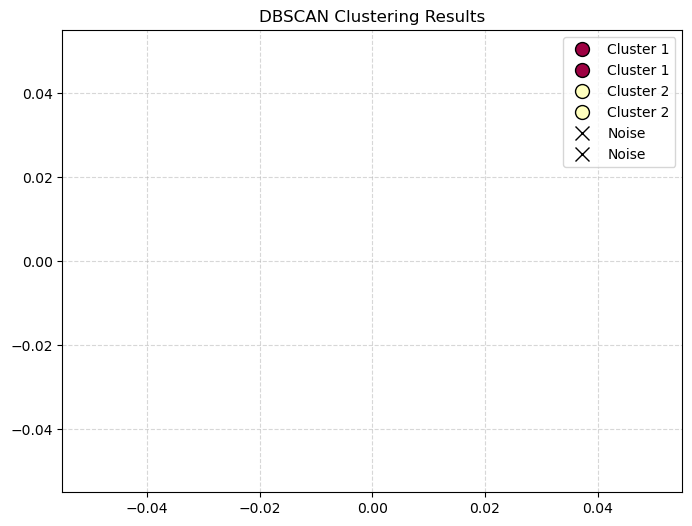

In [9]:
X = np.array(dataset)

# 2. Plotting
plt.figure(figsize=(8, 6))

# Get all unique labels (e.g., 0, 1, -1)
unique_labels = set(labels)

# Define colors (using a colormap)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Style for NOISE (Black, small x)
        col = 'black' 
        marker = 'x'
        label_name = "Noise"
    else:
        # Style for CLUSTERS (Color, circle)
        marker = 'o'
        label_name = f"Cluster {k}"

    # Filter points belonging to this label
    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    
    plt.plot(xy[:, 0], xy[:, 1], marker, markerfacecolor=col, 
             markeredgecolor='k', markersize=10, label=label_name)

plt.title('DBSCAN Clustering Results')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Load the data
df = pd.read_csv('placement.csv')

# 2. Select the relevant features 
# Assuming your CSV has columns like 'cgpa' and 'placement_exam_marks'.
# We use .iloc[:, :] to pick the columns if you don't know the names.
# For this example, let's assume we want the first two numerical columns.
X = df.iloc[:, [0, 1]].values  # Adjust indices [0, 1] based on your actual columns

# 3. CRITICAL: Scale the data
# DBSCAN works poorly if data isn't on the same scale (e.g., 0 to 1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to list format for our custom function
data_points = X_scaled.tolist()

In [4]:
# 4. Define Parameters
# eps=0.5: Radius of neighborhood (since data is scaled, 0.3 to 0.5 is usually good)
# min_points=5: Minimum points to form a dense region
epsilon = 0.5
min_pts = 5

# 5. Run the algorithm
# (Ensure the 'dbscan' function from the previous step is defined in your notebook)
my_labels = dbscan(data_points, epsilon, min_pts)

# Add the labels back to your dataframe to see who belongs where
df['cluster_label'] = my_labels

print(df.head())

   cgpa  placement_exam_marks  placed  cluster_label
0  7.19                  26.0       1              1
1  7.46                  38.0       1              1
2  7.54                  40.0       1              1
3  6.42                   8.0       1              1
4  7.23                  17.0       0              1


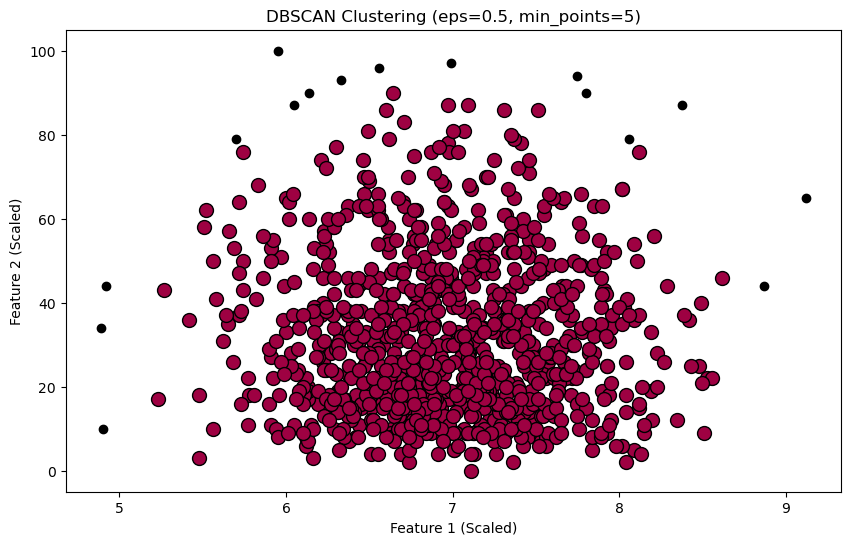

In [5]:
# Convert labels to numpy array for easy indexing
labels = np.array(my_labels)

# Plotting
plt.figure(figsize=(10, 6))

# Plot the clusters (Label != -1)
# We loop through unique labels to give them different colors
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)
    
    # Plot points for this cluster
    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10 if k != -1 else 6)

plt.title(f'DBSCAN Clustering (eps={epsilon}, min_points={min_pts})')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.show()